# $$ \textbf{Sinais e Sistemas Dinâmicos - Aula 04}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Análise Linear de Sistemas Dinâmicos, José C. Geromel, Alvaro G. B. Palhares. ed. Blucher, 2019.]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

#### 2.2.1 Sinais a Tempo Discreto
Os sinais a tempo discreto são aqueles com domínio $\mathbb{Z}$ e com imagem em $\mathbb{R}$ ou $\mathbb{C}$. Vamos seguir exibindo resultados similares àqueles que apresentamos na seção anterior. Em larga medida, quase tudo pode ser refeito, mas com um ferramental matemático um pouco diverso. É preciso alertar que, em geral, calcular somas é mais trabalhoso e mais complicado do que calcular integrais.

**Definição 2.4 (Produto escalar)** O produto escalar de dois sinais $f(k)$ e $g(k)$ com o mesmo domínio $\mathbb{Z}$ e imagem $\mathbb{C}$ é um número complexo dado por
$$
\langle f, g\rangle=\sum_{k=-\infty}^{\infty} f(k) g(k)^*
$$
Assim definido, o produto escalar satisfaz os axiomas da simetria (conjugada), da distributividade, da homogeneidade e da positividade. Em consequência, a norma induzida é então dada por
$$
\|f\|=\sqrt{\langle f, f\rangle}=\sqrt{\sum_{k=-\infty}^{\infty}|f(k)|^2}
$$
e é importante ressaltar a possibilidade da soma indicada divergir. 

A norma de um sinal constante no tempo é $+\infty$. Para que a sua norma seja finita é necessário (mas não suficiente) que $|f(k)| \rightarrow 0$ quando $|k| \rightarrow \infty$. Podemos então concluir que todo sinal periódico tem norma infinita. Uma outra medida do tamanho de um sinal é dada em seguida.

**Definiçāo 2.5 (Valor eficaz)** O valor eficaz de um sinal $f(k)$ com domínio $\mathbb{Z}$ e imagem $\mathbb{C}$ é um número real não negativo dado por
$$
\|f\|_{e f}=\sqrt{\lim _{m \rightarrow \infty} \frac{1}{2 m+1} \sum_{k=-m}^m|f(k)|^2}
$$
Como o intervalo a tempo discreto $[-m, m]$ tem $2 m+1$ elementos, o valor eficaz de um sinal a tempo discreto tem também a simples interpretação de valor médio do seu módulo. Desta forma, para um sinal limitado no tempo por uma constante $\alpha$, obtém-se $\|f\|_{e f} \leq \alpha$. 

O valor eficaz de um sinal constante no tempo é igual ao módulo desta constante. 

O valor eficaz de um sinal periódico é igual ao valor eficaz calculado em apenas um período. De fato, considerando a definição acima com a mudança de variável $m = nN_0$, onde $N_0 \in \mathbb{N}$, é o período fundamental, temos
$$
\begin{aligned}
\|f\|_{e f}^2 & =\lim _{n \rightarrow \infty} \frac{1}{(2nN_0+1)} \sum_{k=-nN_0}^{nN_0} |f(k)|^2 \\
& = \lim _{n \rightarrow \infty} \frac{1}{(2nN_0+1)}(2n) \sum_{k=0}^{N_0} |f(k)|^2  \\
& =\frac{1}{N_0} \sum_{k=0}^{N_0}|f(k)|^2
\end{aligned}
$$

Como já foi possível notar, para manipular sinais a tempo discreto devemos ter bastante destreza com séries, inclusive envolvendo números complexos. Nesta direção, um dos resultados mais básicos entre os mais importantes é dado no seguinte lema. Ele torna explícita a condição de convergência da soma dos elementos de uma progressão geométrica com razão complexa.

**Lema 2.1** Considere $1 \neq z \in \mathbb{C}$ e $1 \leq i \in \mathbb{N}.$

A igualdade
$$
\sum_{k=0}^{i-1} z^k=\frac{1-z^i}{1-z}
$$
é verdadeira. 

Além disso, $\sum_{k=0}^{\infty} z^k=1 /(1-z)$ converge se e somente se $|z|<1$.


Prova: A prova é simples e bastante conhecida. Definido $S=1+z+\cdots+z^{(i-1)}$, então a multiplicação por $z$ leva a $z S=z+z^2+\cdots+z^i$. A subtração permite calcular $(1-z) S=1-z^i$, que fornece o resultado, pois $z \neq 1$. 

O cálculo do limite para $i \rightarrow \infty$ pode ser feito desde que $\lim _{i \rightarrow \infty} z^i$ exista. Como $\left|z^i\right|=|z|^i$, isso é assegurado se e apenas se $|z|<1$. Neste caso, o referido limite é nulo e a igualdade desejada é obtida. $\blacksquare$


A sequência de números complexos
$$
1, z, z^2, z^3, \cdots, z^{(i-1)}
$$

ao ser vista como uma progressão geométrica com razão $z \in \mathbb{C}$ permite afirmar que o Lema 2.1 generaliza para o campo complexo, um resultado já bastante conhecido para sequências reais. 

Os exemplos resolvidos em seguida ilustram os diversos aspectos das duas últimas definições no contexto de sinais a tempo discreto. Em particular, eles são importantes para indicar como as diversas somas que aparecem nas mencionadas definições são calculadas com auxílio do Lema 2.1. 

A estratégia consiste em utilizar a fórmula de Euler para converter funções trigonométricas em exponenciais complexas. Assim procedendo, somas de funções trigonométricas se convertem em somas de progressões geométricas que são manipuladas sem dificuldade. Entretanto, é preciso ficar alerta para aos limites da soma no Lema 2.1 (inicia em $k=0$ e termina em $k=i-1$, envolvendo portanto $i \in \mathbb{N}$ elementos).

Por outro lado, o resultado do Lema 2.1 pode ser manipulado sem qualquer problema desde que se observe o seu domínio de validade. Assim sendo, derivando em relação a $z$ ambos os lados da soma infinita de potências, obtemos uma nova igualdade
$$
\sum_{k=0}^{\infty} k z^k=\frac{z}{(1-z)^2}
$$
que é válida para todo $z \in \mathbb{C}$ tais que $|z|<1$. Este tipo de manipulação algébrica permite obter várias relações úteis, sobretudo no âmbito de sinais a tempo discreto.




In [2]:
z = sym.Symbol('z')
k = sym.Symbol('k')
expr = k*z**k
s = Sum(expr, (k, 0, oo))
s.doit()

Piecewise((z/(1 - z)**2, Abs(z) < 1), (Sum(k*z**k, (k, 0, oo)), True))

**Exemplo 2.9** Sejam os sinais $f(t)$ e $g(t)$ a tempo contínuo, considerados no Exemplo 2.4 e $T>0$ um escalar dado. Define-se o sinal a tempo discreto $s(k)=f(k T)=e^{\alpha T k}$ com domínio $\mathbb{Z}$ e imagem $\mathbb{R}_{+}$. Sua norma sempre é $+\infty$ para qualquer valor de $\alpha \in \mathbb{R}$. Seu valor eficaz é $+\infty$ para todo $\alpha \neq 0$ e é igual a $\|f\|_{e f}=1$ para $\alpha=0$. 

Note que o sinal $h(k)=g(k T)=e^{(\alpha+j \beta) T k}$ com domínio $\mathbb{Z}$ e imagem $\mathbb{C}$ é tal que $|h(k)|=s(k)=|s(k)|$ para todo $k \in \mathbb{Z}$. Assim sendo, a norma e o valor eficaz de $s(k)$ e de $h(k)$ coincidem. A norma e o valor eficaz de $h(k)$ nāo dependem de $\beta \in \mathbb{R}$.


**Exemplo 2.10** Considere o sinal senoidal $f(t)$ já estudado no Exemplo 2.5 e $T>$ 0 dado. Definimos o seguinte sinal a tempo discreto, resultante de uma operação de amostragem periódica, como sendo $s(k)=f(k T)=a$ sen $(\omega T k)$ com domínio $\mathbb{Z}$ e imagem $[-a, a] \subset \mathbb{R}$, em que $a>0$ e $\theta=\omega T \in(0, \pi)$. 

Em primeiro lugar, desejamos saber se este sinal é periódico. Devemos determinar o menor valor de $N_0>0$ tal que $f(k)=f\left(k+N_0\right)$ para todo $k \in \mathbb{Z}$ e $k+N_0 \in \mathbb{Z}$. Desenvolvendo o lado direito da igualdade $\operatorname{sen}(\theta k)=$ $\operatorname{sen}\left(\theta\left(k+N_0\right)\right)$, verificamos que ela é satisfeita se e apenas se $\cos \left(\theta N_0\right)=1$, ou seja $N_0=q(2 \pi / \theta)$ para algum $q \in \mathbb{Z}$. Como $N_0$ tem que ser um número natural, concluímos que $s(k)$ é um sinal periódico desde que a relaçāo $2 \pi / \theta$ seja um número racional. 

Sendo ou nāo periódico, vamos fazer os cálculos sem levar em conta esta informaçāo. Lembrando que a funçāo cosseno é par, temos 

$$
\begin{aligned}
\sum_{k=-m}^m \operatorname{sen}^2(\theta k) & =\frac{1}{2} \sum_{k=-m}^m(1-\cos (2 \theta k)) \\
& =\frac{2 m+1}{2}-\frac{1}{2} \sum_{k=-m}^m \cos (2 \theta k) \\
& =\frac{2 m+1}{2}-\frac{1}{2}\left(1+2 \sum_{k=1}^m \cos (2 \theta k)\right)
\end{aligned}
$$
Resta determinar a soma das funções cosseno. 

Aplicando-se o Lema 2.1 e após algumas manipulações algébricas, temos
$$
\begin{aligned}
1+2 \sum_{k=1}^m \cos (2 \theta k) & =1+\sum_{k=1}^m\left(e^{j 2 \theta k}+e^{-j 2 \theta k}\right) \\
& =\frac{\cos (2 \theta m)-\cos (2 \theta(m+1))}{1-\cos (2 \theta)} \\
& \leq \frac{2}{1-\cos (2 \theta)}
\end{aligned}
$$


Os cálculos anteriores indicam que $\|s\|=+\infty$. 

Por outro lado, temos que $\|s\|_{e f}=a / \sqrt{2}$, que é exatamente igual ao valor eficaz do sinal a tempo contínuo estudado no Exemplo 2.5. 

Os casos extremos caracterizados pelos ângulos $\theta=0$ ou $\theta=\pi$ geram sinais nulos, ou seja, $s(k)=0$ para todo $k \in \mathbb{Z}$, o que leva obviamente a $\|s\|=\|s\|_{e f}=0$.

**Lema 2.2** $$1 + 2^2 + 3^2 + \cdots + n^2 = \frac{n(n+1)(2n + 1)}{6}$$.

Prova: esta demonstração é um exercício recorrente do princípio de indução finita [Elon Lages Lima Análise Real, Volume 1 Funções de uma Variável IMPA (2006)]. Aqui, vamos fazê-la diretamente. 


Inicialmente, vamos observar a conhecida identidade
$$
(n+1)^3=n^3 +3n^2 + 3n+1
$$

Atribuindo-se os valores de $n=0,1,2, \ldots, n$, temos
$$
\begin{array}{llll}
n &=0:(0+1)^3&=1^3 & =0^3+3.0^2+3.0+1 \\
n &=1:(1+1)^3&=2^3 & =1^3+3.1^2+3.1+1 \\
n &=2:(2+1)^3&=3^3 & =2^3+3.2^2+3.2+1 \\
n &=3:(3+1)^3&=4^3 & =3^3+3.3^2+3.3+1 \\
n &=4:(4+1)^3&=5^3 & =4^3+3.4^2+3.4+1 \\
&\vdots &\vdots &\vdots\\
n &=n:(n+1)^3&=(n+1)^3 &=n^3+3 n^2+3 n+1
\end{array}
$$
Somando as identidades acima, 
$$
1^3+2^3+3^3+\ldots+(n+1)^3= 1^3+2^3+3^3+\ldots+n^3 +  3\left(1^2+2^2+3^2+\ldots+n^2\right)+3(1+2+3+\ldots+n)+(n+1)
$$

Simplificando a expressão acima e denotando-se $1^2+2^2+3^2+\ldots+n^2 = S$, temos que

$$
(n+1)^3 = 3S + 3\frac{n(n+1)}{2} + n + 1 
$$
De onde obtemos, 
$$
S = \frac{n(n+1)(2n+1)}{6} \qquad \square
$$

In [3]:
n = Symbol('n')
m = Symbol('m')
expr = m**2

s = Sum(expr, (m, 1, n))
factor(s.doit())


n*(n + 1)*(2*n + 1)/6

**Exemplo 2.11** Considere o sinal $f(t)$ a tempo contínuo, com período $T_0>0$, denominado dente de serra, estudado no Exemplo 2.6. Definimos o sinal periódico, a tempo discreto, cujo primeiro período $|k| \leq r \in \mathbb{N}$ é dado por $s(k)=f(h k)=a h k, \operatorname{com} a>0$ e $r=T_0 / 2 h$. O valor de $h>0$ foi escolhido de forma a fazer com que $r \in \mathbb{N}$. Assim sendo, observe que o sinal $s(k)$ é periódico com período $N_0=2 r+1$. A sua norma é $+\infty$ e o seu valor eficaz é determinado por uma relação equivalente a (2.29), isto é,
$$
\begin{aligned}
\|f\|_{e f}^2 & =\frac{(a h)^2}{2 r+1} \sum_{k=-r}^r k^2 \\
& = \frac{2(a h)^2}{2 r+1} \sum_{k=1}^r k^2\\
& = \frac{(a h)^2(r)(r + 1)}{3}
\end{aligned}
$$
onde utilizamos o Lema 2.2. Substituindo o valor de $r$, obtemos
$$
\|f\|_{c f}=\frac{a T_0}{2 \sqrt{3}} \sqrt{1+\frac{2 h}{T_0}}
$$
Comparando com o caso a tempo contínuo nota-se que o valor eficaz do sinal discreto $s(k)$ é sempre maior que o valor eficaz de $f(t)$. Esses valores tornam-se arbitrariamente próximos desde que o passo de discretização $h$ satisfaça $h \ll T_0 / 2$, isto é, seja muito pequeno se comparado com meio período do sinal $f(t)$.

No caso de sinais a tempo discreto, também é importante considerar o cálculo de normas para sinais obtidos como resultado da combinação linear de um certo número de sinais elementares $f_1(k), \cdots, f_m(k)$, ou seja,
$$
g(k)=\sum_{i=1}^m c_i f_i(k)
$$
em que $c_i \in \mathbb{C}$ para todo $i=1, \cdots, m$ são escalares conhecidos. Aplicando a definição de norma e fazendo uso da sua distributividade, obtemos
$$
\|g\|^2=\sum_{i=1}^m \sum_{n=1}^m c_i c_j^*\left\langle f_i, f_n\right\rangle
$$
o que coloca em evidência que a igualdade
$$
\|g\|^2=\sum_{i=1}^m\left|c_i\right|^2\left\|f_i\right\|^2
$$
se verifica para sinais elementares que satisfaçam as relações
$$
\left\langle f_i, f_n\right\rangle=\sum_{k=-\infty}^{\infty} f_i(k) f_n(k)^*=0
$$

para todo $i \neq n=1, \cdots, m$. 

Se estes sinais elementares forem ortonormais, então a norma quadrática se reduz a $\|g\|^2=\left|c_1\right|^2+\cdots+\left|c_m\right|^2$. Podemos interpretar um conjunto destes sinais elementares como uma base que permite escrever outros sinais a partir de combinações lineares específicas. A determinação de conjuntos de sinais ortonormais é um tema de grande relevância que será abordado mais adiante. A seguinte definição, embora idêntica ao caso a tempo contínuo, será incluída para tornar mais fácil a leitura.

**Definição 2.6** (Sinal par e sinal ímpar) Um sinal $f(k)$ com dominio $\mathbb{Z}$ é denominado **par** se $f(k)=f(-k)$ para todo $k \in \mathbb{Z}$ e é denominado **ímpar** se $f(k)=-f(-k)$ para todo $k \in \mathbb{Z}$.

É claro que um sinal qualquer pode não ser par nem ímpar, mas qualquer sinal pode ser decomposto na forma $f(k)=f_p(k)+f_i(k)$, em que $f_p(k)$ é a sua componente par e $f_i(k)$ é a sua componente ímpar, que são dadas por
$$
\begin{aligned}
f_p(k) & =\frac{1}{2}(f(k)+f(-k)) \\
f_i(k) & =\frac{1}{2}(f(k)-f(-k))
\end{aligned}
$$

A partir da simples aplicação da definição conclui-se que, de fato, o sinal $f_p(k)$ é par e que o sinal $f_i(k)$ é ímpar. É também possível verificar que para qualquer sinal as suas componentes par e ímpar são ortogonais. Esta importante propriedade decorre do cálculo do produto escalar $\left\langle f_p, f_i\right\rangle$ exatamente como foi feito no caso a tempo contínuo. Em muitas situaçōes é útil lembrar que, para qualquer sinal $f(k)$, o sinal produto a ele associado $s(k)=f(k) f(-k)$ é sempre um sinal par. Observe que o mesmo não ocorre com o sinal resultante da divisão $f(k) / f(-k)$, ainda que esta operação possa ser realizada para todo $k \in \mathbb{Z}$.

**Exemplo 2.12** Seja o sinal a tempo contínuo $f(t)=e^{-|t-1|}$ com domínio $t \in \mathbb{R}$. A partir dele construímos o sinal a tempo discreto $s(k)=f(k h)$ com domínio $k \in \mathbb{Z}$. 


A Figura 2.4 mostra as componentes par e ímpar de cada sinal no intervalo de tempo $t \in[-5,5]$ e $k \in[-10,10]$. A fim de representar ambos os sinais na mesma abscissa temporal, para o sinal a tempo discreto consideramos $t=h k $ com $k \in[-10,10]$ e $h=0,5$. 

Pode-se verificar numericamente que, em ambos os casos, as componentes par e ímpar são ortogonais.

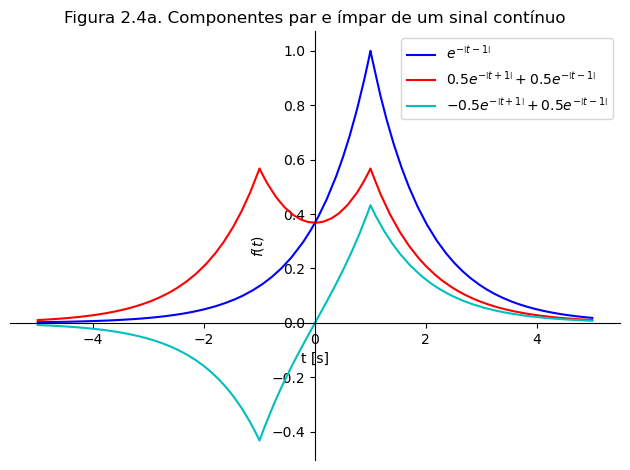

In [4]:
t = sym.Symbol('t')
s1 = exp(-abs(t-1))
s2 = 0.5*(exp(-abs(t-1)) + exp(-abs(-t-1)))
s3 = 0.5*(exp(-abs(t-1)) - exp(-abs(-t-1)))
p = sym.plot(s1, s2, s3, (t, -5, 5), title='Figura 2.4a. Componentes par e ímpar de um sinal contínuo',\
             xlabel='t [s]', legend=True, show = False)

p[0].line_color = 'b'
p[1].line_color = 'r'
p[2].line_color = 'c'
p.show()

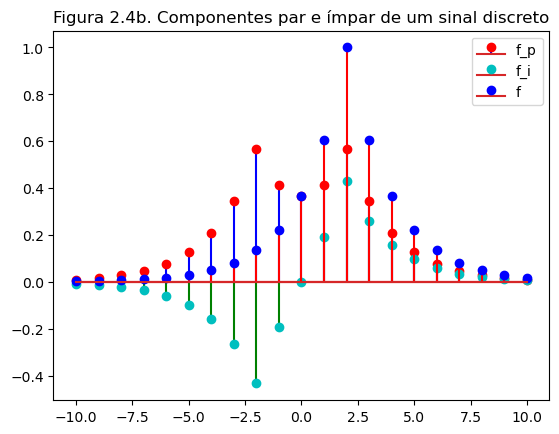

In [8]:
z = []
z1 = []
z2 = []
for k in range(-10,11):
    z.append(k)
    z1.append(exp(-abs(k*0.5-1)))
    z2.append(exp(-abs(-k*0.5-1)))
s1 = z1
s2 = [(a + b)*0.5 for a, b in zip(z1, z2)]
s3 = [(a - b)*0.5 for a, b in zip(z1, z2)]

plt.stem(z, s2, 'b', markerfmt='ro', label='f_p')
plt.stem(z, s3, 'g', markerfmt='co', label='f_i')
plt.stem(z, s1, 'r', markerfmt='bo', label='f')
plt.legend()
plt.title('Figura 2.4b. Componentes par e ímpar de um sinal discreto')
plt.show()

**Exemplo 2.13** (Energia e Potência) De maneira similar aos sinais a tempo contínuo, para os sinais a tempo discreto a quantidade $E=\|f\|^2$ quando finita classifica-o como um **sinal de energia**. Por outro lado, se $P=\|f\|_{ef}^2$ for finita ele é classificado como um **sinal de potência**. Eventuais interpretaçōes físicas dessas quantidades sāo feitas de maneira aproximada via amostragem.

No estudo de sinais a tempo discreto também existem algumas funções que são especiais e que, portanto, merecem ser apresentadas de maneira mais detalhada. Todas elas são definidas no domínio $k \in \mathbb{Z}$ e têm imagem em $\mathbb{R}$.

- **Degrau unitário**: Trata-se de uma das funçōes mais importantes no estudo de sinais. Ela é definida por
$$
v(k)= \begin{cases}1, & k \geq 0 \\ 0, & k<0\end{cases}
$$
e observe que $v(0)=1$.
- **Retângulo unitário**: Trata-se de uma função usada para selecionar partes simétricas (em relaçāo à origem) de sinais. Ela é definida na forma
$$
\vartheta(k)= \begin{cases}1, & |k| \leq n \\ 0, & |k|>n\end{cases}
$$
sendo $1 \leq n \in \mathbb{N}$. Ela pode ser escrita como uma composição de dois degraus unitários deslocados, ou seja, $\vartheta(k)=v(k+n)-v(k-n-1)$. É claro que a sua largura pode ser alterada segundo o valor de $n \in \mathbb{N}$ escolhido.

Por fim, desejamos introduzir o chamado impulso unitário, que tem importância singular no estudo de sinais (e de sistemas) a tempo discreto. Como é usual, adotamos a mesma notaçāo $\delta(k)$, mas *se trata de um ente matemático muito diferente do impulso unitário a tempo contínuo* e é definido por

- **impulso unitário**:
$$
\delta(k)= \begin{cases}1, & k=0 \\ 0, & k \neq 0\end{cases}
$$
Em algumas situações é conveniente identificar $\delta(k)=0^k$, tomando-se $0^0=1$, por convenção. 

A seguinte igualdade se estabelece

$$
\sum_{k=-\infty}^{\infty} f(k) \delta(k-n)=f(n)
$$
a qual seleciona, para cada $n \in \mathbb{Z}$ dado, o valor da função $f(k)$ no instante $k=n \in \mathbb{Z}$. Como $\delta(k-n)=0$ para todo $k \neq n$ e $\delta(k-n)=1$ para $k=n$, verifica-se a validade da relação acima de maneira trivial. 

Funções elementares podem ser escritas com o impulso unitário. O degrau unitário é uma delas
$$
v(k)=\sum_{n=-\infty}^k \delta(n)
$$
como pode ser verificado sem dificuldades. O impulso unitário em tempo discreto não tem as singularidades do seu homônimo $\delta(t)$ em tempo contínuo. São entidades matemáticas diversas. Como já foi dito, ambos têm grande utilidade não só no estudo de sinais, mas também no estudo de sistemas dinâmicos.

Vale ressaltar que tudo foi feito para sinais com imagem em $\mathbb{C}$. Os mesmos resultados para o caso específico de sinais com imagem em $\mathbb{R}$ decorrem de forma imediata. Trabalhar diretamente com o conjunto $\mathbb{C}$ facilita os cálculos, mas requer uma certa destreza com números complexos e funçōes de variável complexa.

